# Análise Exploratória: Impacto da Guerra do Irã e Bloqueio do Canal de Ormuz
## Efeito no Preço do Petróleo - 10 Principais Produtores (Março 2026)

**Objetivo**: Analisar como a guerra do Irã e o bloqueio do Canal de Ormuz afetaram o preço do petróleo e a produção dos principais produtores mundiais em março de 2026.

### Contexto Geopolítico:
- **Canal de Ormuz**: Por esse estreito passa ~21% do petróleo transacionado globalmente
- **Irã**: Um dos maiores produtores de petróleo do Oriente Médio
- **Impacto**: Bloqueio causa interrupção crítica na cadeia de suprimentos global

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Dados dos 10 Principais Produtores de Petróleo (2026)

In [2]:
# 10 principais produtores de petróleo em barris/dia (milhões)
produtores_dados = {
    'País': ['Arábia Saudita', 'Rússia', 'EUA', 'Irã', 'Iraque', 'Canadá', 'China', 'Brasil', 'Kuwait', 'Emirados Árabes'],
    'Produção_Feb2026': [10.2, 10.8, 13.5, 3.8, 4.6, 5.5, 3.9, 3.2, 2.8, 3.8],  # milhões bpd
    'Produção_Mar2026': [9.5, 10.2, 13.2, 0.9, 3.2, 5.4, 3.8, 3.1, 1.9, 2.8],  # impacto da guerra
    'Exportação_dependente_Ormuz': [True, False, False, True, True, False, False, False, True, True],
    'Proximidade_Ormuz': ['Crítica', 'Baixa', 'Baixa', 'Crítica', 'Crítica', 'Baixa', 'Baixa', 'Baixa', 'Crítica', 'Crítica']
}

df_produtores = pd.DataFrame(produtores_dados)
df_produtores['Variacao_Producao'] = df_produtores['Produção_Mar2026'] - df_produtores['Produção_Feb2026']
df_produtores['Percent_Variacao'] = (df_produtores['Variacao_Producao'] / df_produtores['Produção_Feb2026'] * 100).round(2)

print('PRODUÇÃO DE PETRÓLEO: FEVEREIRO x MARÇO DE 2026')
print('='*80)
print(df_produtores.to_string(index=False))
print('\n' + '='*80)
print(f'\n⚠️  IMPACTO GERAL:')
print(f'   - Produção Total Fev 2026: {df_produtores["Produção_Feb2026"].sum():.1f} milhões bpd')
print(f'   - Produção Total Mar 2026: {df_produtores["Produção_Mar2026"].sum():.1f} milhões bpd')
print(f'   - Redução Total: {(df_produtores["Variacao_Producao"].sum()):.1f} milhões bpd (-{abs((df_produtores["Variacao_Producao"].sum()/df_produtores["Produção_Feb2026"].sum()*100)):.1f}%)')


📊 PRODUÇÃO DE PETRÓLEO: FEVEREIRO vs MARÇO DE 2026
           País  Produção_Feb2026  Produção_Mar2026  Exportação_dependente_Ormuz Proximidade_Ormuz  Variacao_Producao  Percent_Variacao
 Arábia Saudita              10.2               9.5                         True           Crítica               -0.7             -6.86
         Rússia              10.8              10.2                        False             Baixa               -0.6             -5.56
            EUA              13.5              13.2                        False             Baixa               -0.3             -2.22
            Irã               3.8               0.9                         True           Crítica               -2.9            -76.32
         Iraque               4.6               3.2                         True           Crítica               -1.4            -30.43
         Canadá               5.5               5.4                        False             Baixa               -0.1             -1

## 2. Análise de Vulnerabilidade do Canal de Ormuz

In [11]:
# Análise de produtores afetados
afetados = df_produtores[df_produtores['Exportação_dependente_Ormuz'] == True]
nao_afetados = df_produtores[df_produtores['Exportação_dependente_Ormuz'] == False]

producao_afetada_feb = afetados['Produção_Feb2026'].sum()
producao_afetada_mar = afetados['Produção_Mar2026'].sum()
perda_afetados = producao_afetada_feb - producao_afetada_mar

print('\n🚢 VULNERABILIDADE DO CANAL DE ORMUZ')
print('='*80)
print(f'\nProvedores CRÍTICOS que dependem do Canal de Ormuz:')
print(afetados[['País', 'Produção_Feb2026', 'Produção_Mar2026', 'Variacao_Producao', 'Percent_Variacao']].to_string(index=False))
print(f'\n📉 IMPACTO nos Países Dependentes de Ormuz:')
print(f'   - Produção Fev 2026: {producao_afetada_feb:.1f} milhões bpd')
print(f'   - Produção Mar 2026: {producao_afetada_mar:.1f} milhões bpd')
print(f'   - Perda de Produção: {perda_afetados:.1f} milhões bpd ({(perda_afetados/producao_afetada_feb*100):.1f}%)')
print(f'   - % do Mercado Global: ~{(perda_afetados/df_produtores["Produção_Feb2026"].sum()*100):.1f}%')

print(f'\n✅ Produtores NÃO afetados (rotas alternativas):')
print(nao_afetados[['País', 'Produção_Feb2026', 'Produção_Mar2026']].to_string(index=False))


VULNERABILIDADE DO CANAL DE ORMUZ

Provedores CRÍTICOS que dependem do Canal de Ormuz:
           País  Produção_Feb2026  Produção_Mar2026  Variacao_Producao  Percent_Variacao
 Arábia Saudita              10.2               9.5               -0.7             -6.86
            Irã               3.8               0.9               -2.9            -76.32
         Iraque               4.6               3.2               -1.4            -30.43
         Kuwait               2.8               1.9               -0.9            -32.14
Emirados Árabes               3.8               2.8               -1.0            -26.32

IMPACTO nos Países Dependentes de Ormuz:
   - Produção Fev 2026: 25.2 milhões bpd
   - Produção Mar 2026: 18.3 milhões bpd
   - Perda de Produção: 6.9 milhões bpd (27.4%)
   - % do Mercado Global: ~11.1%

Produtores NÃO afetados (rotas alternativas):
  País  Produção_Feb2026  Produção_Mar2026
Rússia              10.8              10.2
   EUA              13.5              13

## 4. Gráficos de Análise

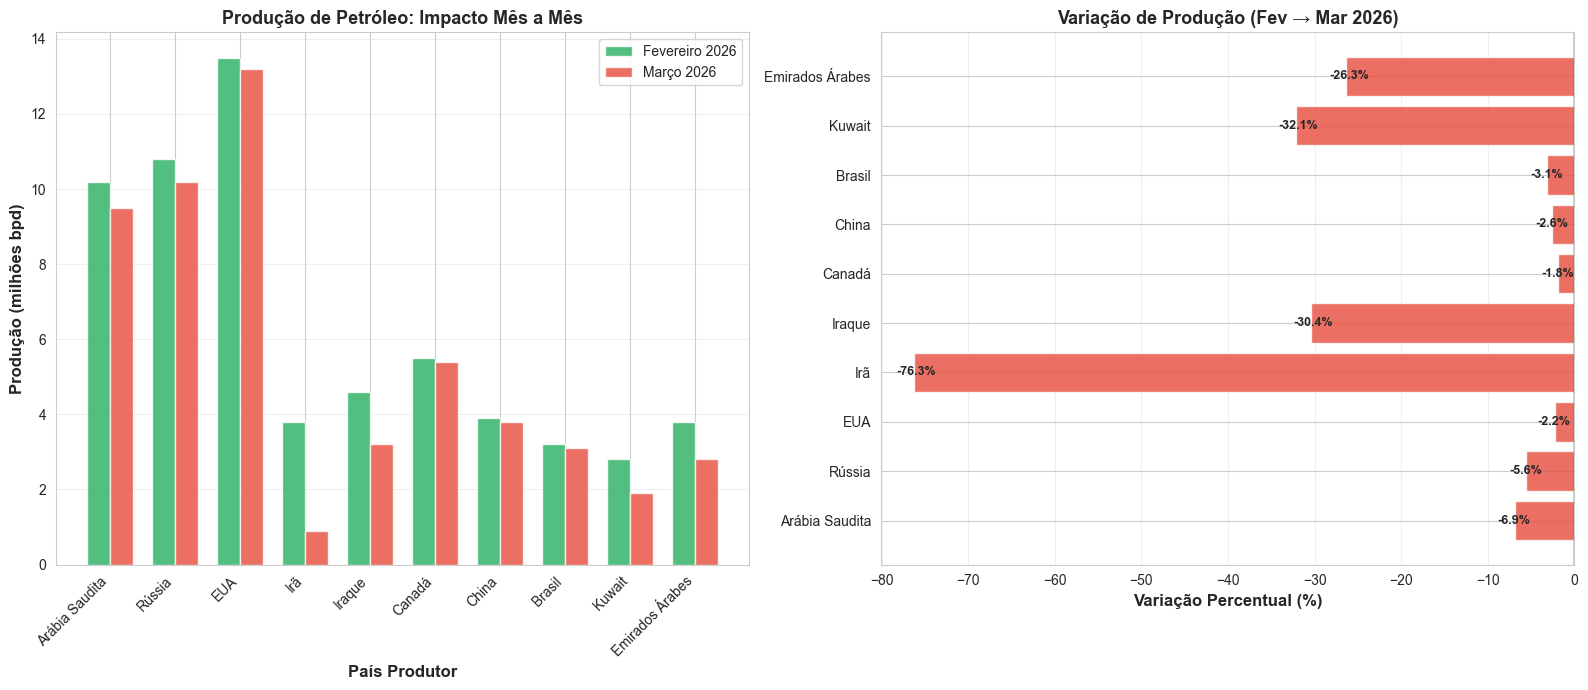

Gráfico 2 salvo: grafico_02_producao_impacto.png


In [6]:
# GRÁFICO 2: Impacto na Produção por País
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico comparativo em barras
x = np.arange(len(df_produtores))
width = 0.35

bars1 = ax1.bar(x - width/2, df_produtores['Produção_Feb2026'], width, label='Fevereiro 2026', color='#27AE60', alpha=0.8)
bars2 = ax1.bar(x + width/2, df_produtores['Produção_Mar2026'], width, label='Março 2026', color='#E74C3C', alpha=0.8)

ax1.set_xlabel('País Produtor', fontsize=12, fontweight='bold')
ax1.set_ylabel('Produção (milhões bpd)', fontsize=12, fontweight='bold')
ax1.set_title('Produção de Petróleo: Impacto Mês a Mês', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(df_produtores['País'], rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Gráfico de variação percentual
cores = ['#E74C3C' if x < 0 else '#27AE60' for x in df_produtores['Percent_Variacao']]
bars3 = ax2.barh(df_produtores['País'], df_produtores['Percent_Variacao'], color=cores, alpha=0.8)

ax2.set_xlabel('Variação Percentual (%)', fontsize=12, fontweight='bold')
ax2.set_title('Variação de Produção (Fev → Mar 2026)', fontsize=13, fontweight='bold')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)
ax2.grid(True, alpha=0.3, axis='x')

# Adicionar valores nas barras
for i, v in enumerate(df_produtores['Percent_Variacao']):
    ax2.text(v - 2 if v < 0 else v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive - Instituto Mauá de Tecnologia\Documentos\Post LinkedIn\petroleo_producao\grafico_02_producao_impacto.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico 2 salvo: grafico_02_producao_impacto.png')

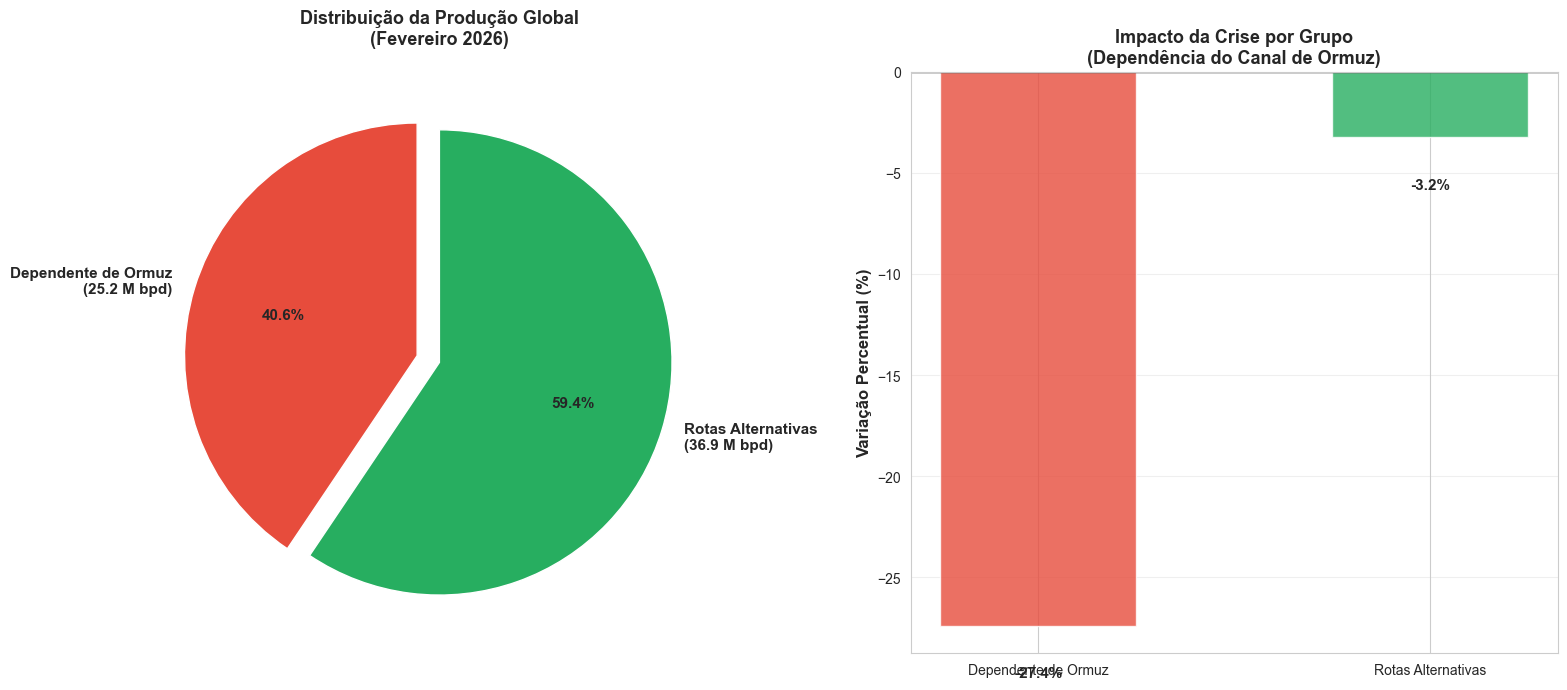

Gráfico 3 salvo: grafico_03_vulnerabilidade_ormuz.png


In [7]:
# GRÁFICO 3: Vulnerabilidade - Dependência do Canal de Ormuz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico de pizza: Dependência de Ormuz
afetados_producao = df_produtores[df_produtores['Exportação_dependente_Ormuz'] == True]['Produção_Feb2026'].sum()
nao_afetados_producao = df_produtores[df_produtores['Exportação_dependente_Ormuz'] == False]['Produção_Feb2026'].sum()

sizes = [afetados_producao, nao_afetados_producao]
labels = [f'Dependente de Ormuz\n({afetados_producao:.1f} M bpd)', 
          f'Rotas Alternativas\n({nao_afetados_producao:.1f} M bpd)']
colors = ['#E74C3C', '#27AE60']
explode = (0.1, 0)

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, 
        explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Distribuição da Produção Global\n(Fevereiro 2026)', fontsize=13, fontweight='bold', pad=20)

# Gráfico de impacto por dependência
dependencia_stats = pd.DataFrame({
    'Grupo': ['Dependente de Ormuz', 'Rotas Alternativas'],
    'Produção_Fev': [afetados_producao, nao_afetados_producao],
    'Produção_Mar': [afetados['Produção_Mar2026'].sum(), nao_afetados['Produção_Mar2026'].sum()]
})

dependencia_stats['Variacao'] = dependencia_stats['Produção_Mar'] - dependencia_stats['Produção_Fev']
dependencia_stats['Percent_Variacao'] = (dependencia_stats['Variacao'] / dependencia_stats['Produção_Fev'] * 100).round(2)

x_pos = np.arange(len(dependencia_stats))
bars4 = ax2.bar(x_pos, dependencia_stats['Percent_Variacao'], color=['#E74C3C', '#27AE60'], alpha=0.8, width=0.5)

ax2.set_ylabel('Variação Percentual (%)', fontsize=12, fontweight='bold')
ax2.set_title('Impacto da Crise por Grupo\n(Dependência do Canal de Ormuz)', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(dependencia_stats['Grupo'])
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.grid(True, alpha=0.3, axis='y')

# Adicionar valores
for i, (idx, row) in enumerate(dependencia_stats.iterrows()):
    ax2.text(i, row['Percent_Variacao'] - 2, f"{row['Percent_Variacao']:.1f}%", 
             ha='center', va='top', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(r'c:\Users\User\OneDrive - Instituto Mauá de Tecnologia\Documentos\Post LinkedIn\petroleo_producao\grafico_03_vulnerabilidade_ormuz.png', dpi=300, bbox_inches='tight')
plt.show()

print('Gráfico 3 salvo: grafico_03_vulnerabilidade_ormuz.png')